## Checking Dataset

In [2]:
library(readr)
library(dplyr)

csv_files <- list.files(pattern = "\\.csv$")
csv_files


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




[1] "Catoctin_FishData.csv"    "Catoctin_FishHabitat.csv"
[3] "Catoctin_FishSites.csv"   "Catoctin_LoggerSites.csv"
[5] "Catoctin_Temperature.csv"

In [3]:
data <- lapply(csv_files, read_csv, show_col_types = FALSE, na = c("", "NA", "#VALUE!"))
names(data) <- sub("\\.csv$", "", csv_files)

for (nm in names(data)) {
  cat("\n==========", nm, "==========\n")
  cat(nrow(data[[nm]]), "rows x", ncol(data[[nm]]), "columns\n")
  print(names(data[[nm]]))
}


New names:
* `` -> `...24`
* `` -> `...25`



========== Catoctin_FishData ==========
1221 rows x 9 columns
[1] "Date"      "Time"      "Watershed" "ReachID"   "Effort"    "Species"  
[7] "Length"    "Weight"    "Count"    

========== Catoctin_FishHabitat ==========
1225 rows x 25 columns
 [1] "Date"                 "Time"                 "Watershed"           
 [4] "ReachID"              "Transect"             "WettedWidth"         
 [7] "MesohabitatL"         "MesohabitatM"         "MesohabitatR"        
[10] "DepthL"               "DepthM"               "DepthR"              
[13] "SubstrateTopL"        "SubstrateBottomL"     "SubstrateTopM"       
[16] "SubstrateBottomM"     "SubstrateTopR"        "SubstrateBottomR"    
[19] "Temp"                 "Single Channel (Y/N)" "Logger (Y/N)"        
[22] "LWD Small Count"      "LWD Large Count"      "...24"               
[25] "...25"               

========== Catoctin_FishSites ==========
64 rows x 3 columns
[1] "ReachID"   "Latitude"  "Longitude"

========== Catoctin_LoggerSites

In [4]:
# Remove columns that are completely empty (FishHabitat has two blank ones at the end)
data <- lapply(data, function(df) df[, colSums(!is.na(df)) > 0])

for (nm in names(data)) {
  cat("\n==========", nm, "==========\n")
  glimpse(data[[nm]])
}



========== Catoctin_FishData ==========
Rows: 1,221
Columns: 9
$ Date      <chr> "7/28/2015", "7/28/2015", "7/28/2015", "7/28/2015", "7/28/20~
$ Time      <time> 10:00:00, 10:00:00, 10:00:00, 10:00:00, 10:00:00, 10:00:00,~
$ Watershed <chr> "Big Hunting", "Big Hunting", "Big Hunting", "Big Hunting", ~
$ ReachID   <chr> "FBB01", "FBB01", "FBB01", "FBB01", "FBB01", "FBB01", "FBB01~
$ Effort    <dbl> 823, 823, 823, 823, 823, 823, 823, 823, 823, 823, 823, 823, ~
$ Species   <chr> "COCA", "ETFL", "RHAT", "RHCA", "SATR", "SATR", "SATR", "SAT~
$ Length    <dbl> NA, NA, NA, NA, 234, 66, 71, 66, 65, 66, 62, 54, 55, 52, 53,~
$ Weight    <dbl> NA, NA, NA, NA, 122.7, 3.1, 3.3, 2.6, 2.5, 2.5, 2.3, 1.4, 1.~
$ Count     <dbl> 9, 4, 90, 1, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, 8, ~

========== Catoctin_FishHabitat ==========
Rows: 1,225
Columns: 24
$ Date                   <chr> "7/2/2015", "7/2/2015", "7/2/2015", "7/2/2015",~
$ Time                   <time> 10:17:00, 10:17:00, 10:17:00, 10:17:

In [5]:
for (nm in names(data)) {
  df <- data[[nm]]
  cat("\n==========", nm, "==========\n")
  print(data.frame(
    type        = sapply(df, function(x) class(x)[1]),
    n_missing   = colSums(is.na(df)),
    pct_missing = round(100 * colMeans(is.na(df)), 1),
    n_unique    = sapply(df, n_distinct)
  ))
}



========== Catoctin_FishData ==========
               type n_missing pct_missing n_unique
Date      character         0         0.0       16
Time            hms         0         0.0       24
Watershed character         0         0.0        2
ReachID   character         0         0.0       64
Effort      numeric         0         0.0       63
Species   character         0         0.0       13
Length      numeric       258        21.1      156
Weight      numeric       258        21.1      307
Count       numeric       965        79.0      113

========== Catoctin_FishHabitat ==========
                          type n_missing pct_missing n_unique
Date                 character         0         0.0       18
Time                       hms        40         3.3       47
Watershed            character         0         0.0        2
ReachID              character         0         0.0       61
Transect               numeric         0         0.0       24
WettedWidth            numeric   

In [6]:
for (nm in names(data)) {
  cats <- select(data[[nm]], where(function(x) is.character(x) && n_distinct(x) <= 30))
  if (ncol(cats) == 0) next
  cat("\n==========", nm, "==========\n")
  for (v in names(cats)) {
    cat("\n--", v, "--\n")
    print(sort(table(cats[[v]], useNA = "ifany"), decreasing = TRUE))
  }
}



========== Catoctin_FishData ==========

-- Date --

7/17/2015 7/16/2015 7/14/2015 7/20/2015  7/6/2015  7/9/2015 7/10/2015  7/8/2015 
      294       149       148        99        82        82        66        57 
 7/7/2015 7/28/2015 7/15/2015 7/27/2015 7/13/2015 7/23/2015 7/21/2015 7/29/2015 
       54        51        41        29        25        20        19         5 

-- Watershed --

      Owens Big Hunting 
       1116         105 

-- Species --

SAFO RHAT SATR COCA SEAT RHCA CLFU ETFL COGI CACO LEMA AMNA MISA 
 903   63   62   50   36   29   26   26   12    9    3    1    1 

========== Catoctin_FishHabitat ==========

-- Date --

7/28/2015 7/13/2015 7/29/2015  7/8/2015  7/9/2015 7/17/2015 7/15/2015  7/7/2015 
      137       116        99        98        84        78        77        73 
7/10/2015 7/27/2015 7/16/2015 7/20/2015 7/21/2015 7/23/2015 7/14/2015  7/6/2015 
       62        62        61        60        60        57        38        24 
 7/2/2015 7/18/2015 
    

In [7]:
fish <- data$Catoctin_FishData

fish <- fish %>%
  mutate(n_fish = ifelse(is.na(Count), 1, Count))   # trout rows = 1 fish each

fish %>%
  group_by(Species) %>%
  summarise(total_fish = sum(n_fish), reaches = n_distinct(ReachID)) %>%
  arrange(desc(total_fish))

fish %>%
  group_by(Watershed, Species) %>%
  summarise(total_fish = sum(n_fish), .groups = "drop") %>%
  arrange(Watershed, desc(total_fish))


Species,total_fish,reaches
<chr>,<dbl>,<int>
RHAT,9211,63
COCA,3973,50
SAFO,903,45
RHCA,318,29
SEAT,306,35
CLFU,267,26
ETFL,230,26
SATR,62,19
COGI,34,12


Watershed,Species,total_fish
<chr>,<chr>,<dbl>
Big Hunting,RHAT,3526
Big Hunting,COCA,145
Big Hunting,SEAT,101
Big Hunting,SATR,46
Big Hunting,SAFO,22
Big Hunting,LEMA,6
Big Hunting,ETFL,4
Big Hunting,MISA,2
Big Hunting,AMNA,1


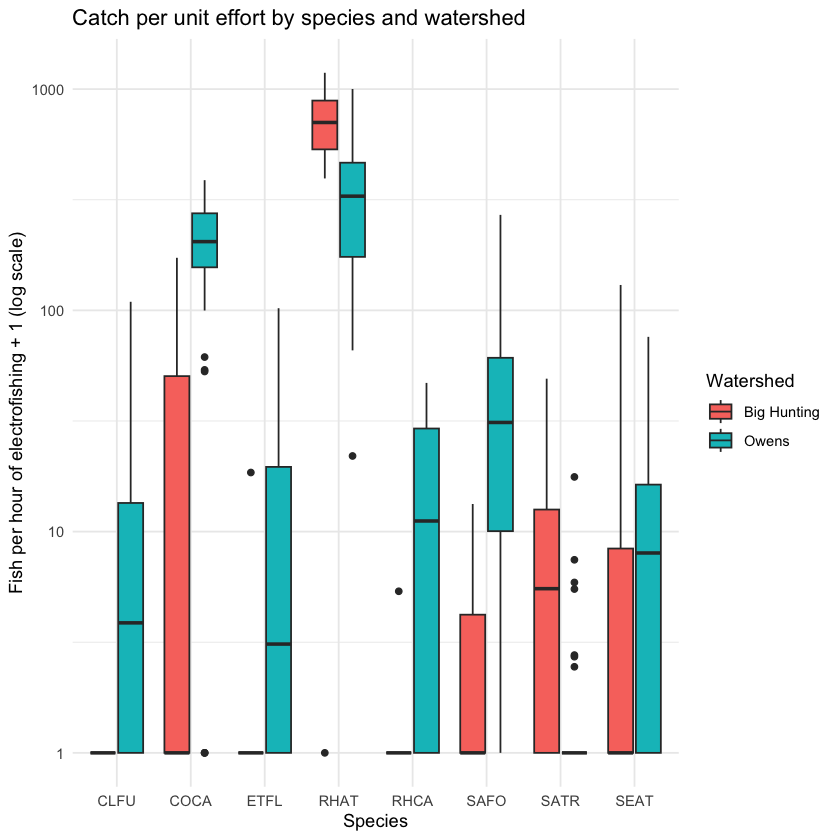

In [8]:
library(ggplot2)

reach_info <- fish %>% distinct(ReachID, Watershed, Effort)

# One row per reach x species; xtabs() puts 0 where a species wasn't caught
cpue <- as.data.frame(xtabs(n_fish ~ ReachID + Species, data = fish), responseName = "n")
cpue <- merge(cpue, reach_info, by = "ReachID")
cpue$cpue_per_hr <- cpue$n / (cpue$Effort / 3600)

main_species <- c("RHAT", "COCA", "SAFO", "SATR", "SEAT", "RHCA", "CLFU", "ETFL")

ggplot(subset(cpue, Species %in% main_species),
       aes(x = Species, y = cpue_per_hr + 1, fill = Watershed)) +
  geom_boxplot() +
  scale_y_log10() +
  labs(y = "Fish per hour of electrofishing + 1 (log scale)",
       title = "Catch per unit effort by species and watershed") +
  theme_minimal()


Loading required package: permute



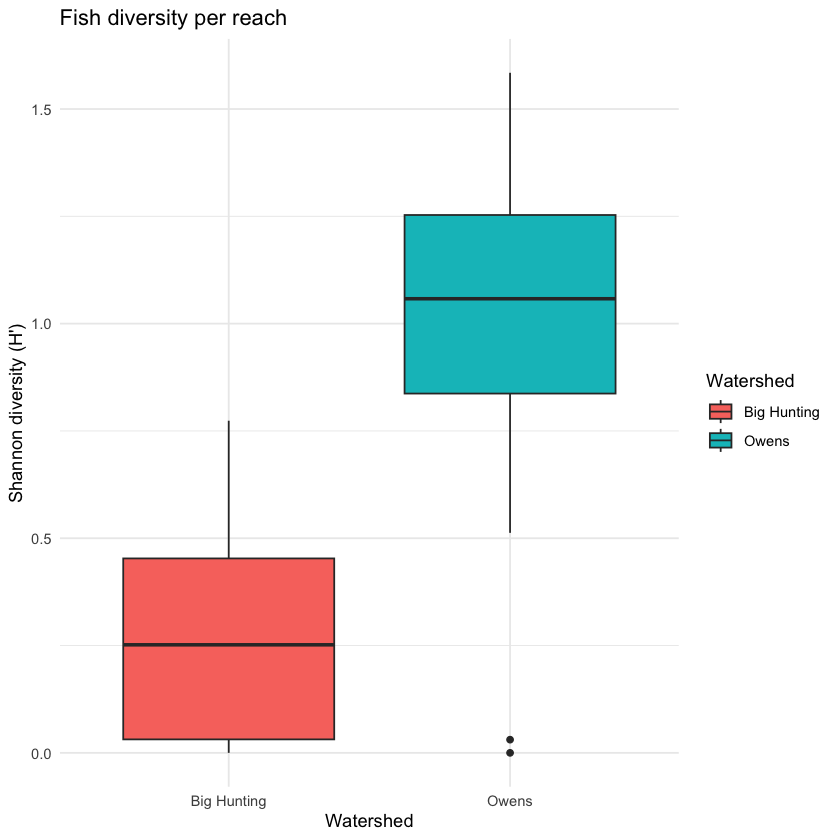

In [9]:
library(vegan)

# Community matrix: rows = reaches, columns = species, values = fish caught
comm <- as.data.frame.matrix(xtabs(n_fish ~ ReachID + Species, data = fish))
reach_info <- reach_info[match(rownames(comm), reach_info$ReachID), ]   # same row order as comm

reach_info$richness <- specnumber(comm)                    # number of species per reach
reach_info$shannon  <- diversity(comm, index = "shannon")  # Shannon diversity per reach

ggplot(reach_info, aes(x = Watershed, y = shannon, fill = Watershed)) +
  geom_boxplot() +
  labs(y = "Shannon diversity (H')", title = "Fish diversity per reach") +
  theme_minimal()


How do stream temperature and habitat shape fish communities in the Catoctin Mountain watersheds, and what does that mean for native brook trout?

### Branch A. Do the fish communities differ between watersheds? This is where you start: it establishes the pattern the other branches explain.

Data: the comm matrix and Watershed.
Methods: species richness, Shannon diversity, NMDS (metaMDS) and PERMANOVA (adonis2).

### Branch B. Is temperature behind the differences? This is the main explanation to test.

Data: summer water temperatures from the loggers, e.g. the mean for July–August or the number of days above 20 °C, matched to the nearest fish reach.
Question to test: are warmer reaches where brown trout and the warm-water species (bluegill, bass, bullhead) show up, and where native brook trout are scarce?

### Branch C. Does habitat structure matter too? This checks for other explanations besides temperature.

Data: per-reach depth, width, % riffle/run/pool, substrate and woody debris.
Methods: envfit() on the NMDS, or relate habitat to catch per hour for key species. For example, test whether sculpin are linked to cobble.

### Branch D. How are brook trout doing where they occur? This focuses on the species with the richest data.

Data: individual lengths and weights.
Methods: a length–weight relationship, body condition (Fulton's K), and whether young fish (under about 90 mm) are present, which shows breeding.
Links: compare these by watershed, temperature (B) and habitat (C).